In [1]:
import awkward as ak
import numpy as np

import matplotlib.pyplot as plt
import mplhep as hep

import hist
from hist import Hist

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from topcoffea.modules.histEFT import HistEFT
NanoAODSchema.warn_missing_crossrefs = False

from coffea.analysis_tools import PackedSelection
from topcoffea.modules import utils
import topcoffea.modules.eft_helper as efth

import re
import pickle, gzip

In [188]:
fname = "/cms/cephfs/data//store/user/hnelson2/skims/mc/ptSkim/PowhegTTto2L2Nu/UL17_TTTo2L2Nu/output_8.root" 
# fname = "/cms/cephfs/data/store/user/hnelson2/mc/central_ttbar_nanoAOD/UL16APV/nanoAOD_TTto2L2Nu_1Jets_smeft_MTT_0to700/NAOD-00000_879.root" #no problem MUF8
# fname="/cms/cephfs/data/store/user/hnelson2/mc/ttbarEFT_Run2/UL17/postLHE/v3/NAOD_TTto2L2Nu_1Jets_smeft_MTT_0to700_v1/NAOD-00000_102885.root" #works MUF9

events = NanoEventsFactory.from_root(
    {fname: "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset": "TTto2L2Nu"},
    mode="eager",
    entry_stop=50000,
).events()

In [189]:
def calculateNNLO_EventWeight(events, dataset):

    NNLO_weight = ak.ones_like(events.event, dtype=float)

    def calculate_NNLO_SF(pt):
        return (np.multiply(0.103, np.exp(-0.0118*pt)) - np.multiply(0.000134, pt) + 0.973)

    if 'mtt' in dataset:
        genpart = events.GenPart
        is_final_mask = genpart.hasFlags(["fromHardProcess","isLastCopy"])
        gen_top = ak.pad_none(genpart[is_final_mask & (abs(genpart.pdgId) == 6)],2)
        top1 = gen_top[:,0]
        top2 = gen_top[:,1]

        NNLO_weight = np.sqrt(calculate_NNLO_SF(top1.pt)*calculate_NNLO_SF(top2.pt))

    return NNLO_weight

In [190]:
genpart = events.GenPart
is_final_mask = genpart.hasFlags(["fromHardProcess","isLastCopy"])
gen_top = ak.pad_none(genpart[is_final_mask & (abs(genpart.pdgId) == 6)],2)
gen_top[ak.argsort(gen_top.pt, axis=1, ascending=False)]
top1 = gen_top[:,0]
top2 = gen_top[:,1]

event_weights = calculateNNLO_EventWeight(events, 'mtt')

In [191]:
orig_h = Hist(hist.axis.Regular(bins=50, start=0, stop=1000, name="top_pt"))
orig_h.fill(top1.pt)

reweighted_h = Hist(hist.axis.Regular(bins=50, start=0, stop=1000, name="top_pt"))
reweighted_h.fill(top1.pt, weight=event_weights)

Hist(Regular(50, 0, 1000, name='top_pt'), storage=Double()) # Sum: 49281.1325289011 (49285.47631162405 with flow)

In [192]:
orig_h

Hist(Regular(50, 0, 1000, name='top_pt'), storage=Double()) # Sum: 49995.0 (50000.0 with flow)

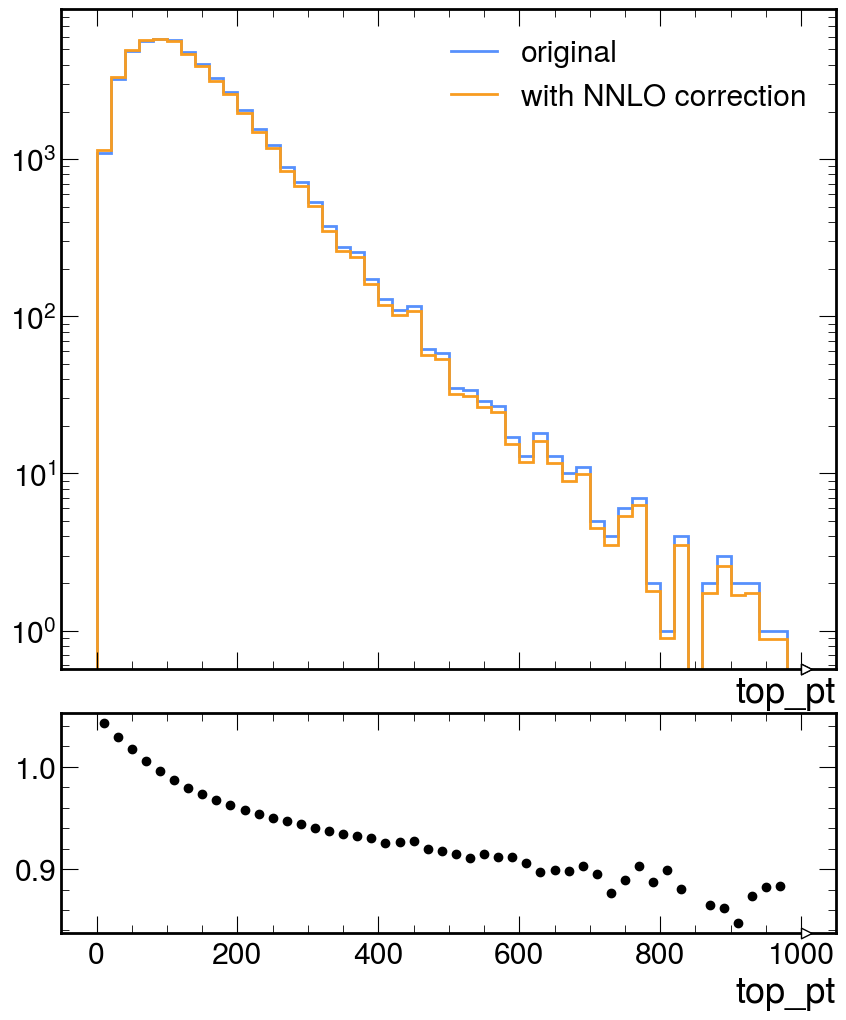

In [31]:
hep.style.use('CMS')
fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10,12),
    gridspec_kw={'height_ratios': (3, 1)},
    sharex=True
)
fig.subplots_adjust(hspace=.1)

hep.histplot(orig_h, ax=ax, stack=False, yerr=False, linewidth=2, label='original')
hep.histplot(reweighted_h, ax=ax, stack=False, yerr=False, linewidth=2, label='with NNLO correction')

ratio = reweighted_h/orig_h
hep.histplot(
    ratio,
    yerr=False,
    histtype='errorbar',
    markersize=12,
    color='black',
    ax=rax,
)  

ax.legend()
ax.set_yscale('log')

In [234]:
NLO_sample = pickle.load(gzip.open("../LOtoNLO/PowhegLOtoNLO.pkl.gz"))
h_NLO = NLO_sample['ttbar']['avg_toppt']

LO_sample = pickle.load(gzip.open("../LOtoNLO/./SMEFTsimLOtoNLO.pkl.gz"))
h_LO = LO_sample['ttbar']['avg_toppt']

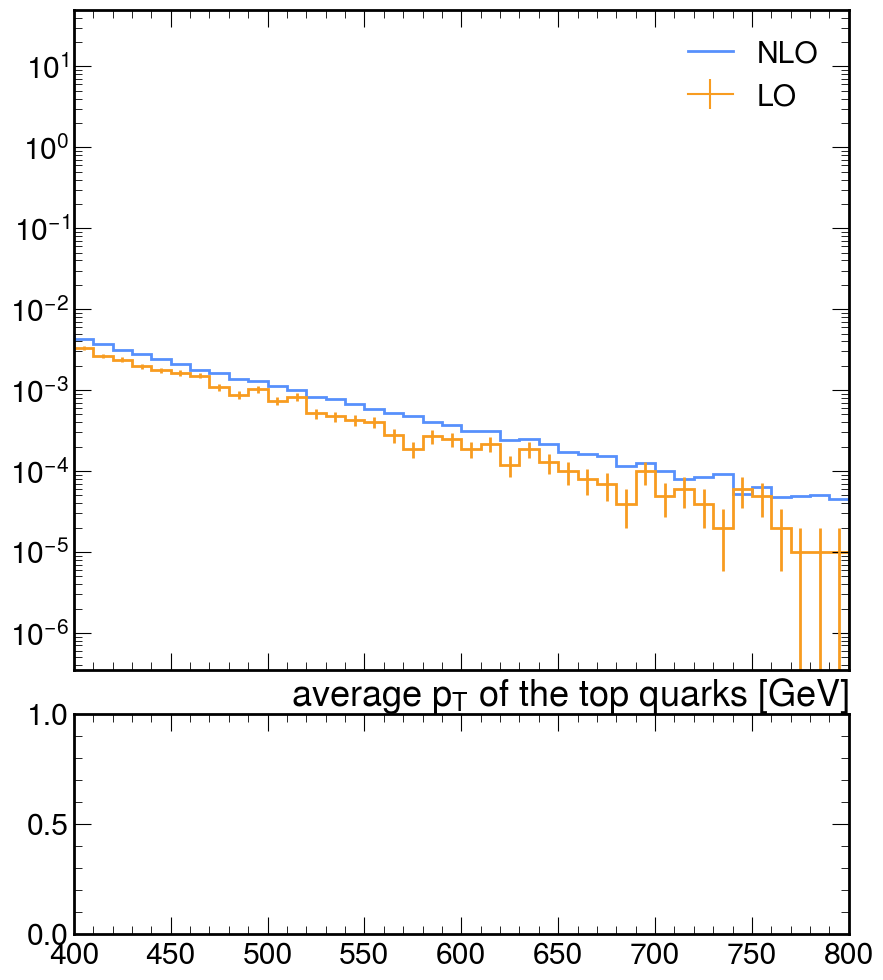

In [237]:
hep.style.use('CMS')
fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10,12),
    gridspec_kw={'height_ratios': (3, 1)},
    sharex=True
)
fig.subplots_adjust(hspace=.1)

hep.histplot(h_NLO, ax=ax, stack=False, yerr=False, linewidth=2, label='NLO')
hep.histplot(h_LO, ax=ax, stack=False, yerr=True, linewidth=2, label='LO')

# ratio = h_LO/h_NLO
# hep.histplot(
#     ratio,
#     yerr=False,
#     histtype='errorbar',
#     markersize=12,
#     color='black',
#     ax=rax,
# )  

ax.legend()
# ax.set_xlim([0,1500])
ax.set_xlim([400,800])
# ax.set_ylim([0.1, 1])
ax.set_yscale('log')

In [38]:
bins = [*list(range(0, 400, 10)), *list(range(400, 600, 20)), *list(range(600, 800, 50)), *list(range(800, 1000, 100)), *list(range(1000, 2001, 500))]

In [ ]:
new_bins = [*list(range(0, 400, 10)), *list(range(400, 600, 20)), *list(range(600, 800, 50)), *list(range(800, 1000, 100)), *list(range(1000, 2001, 500))]
rebin = hist.rebin(groups=[*(np.repeat(1, (400)/10)), *(np.repeat(2, (600-400)/10/2)), 
                           *(np.repeat(5, (800-600)/10/5)), *(np.repeat(10, (1000-800)/10/10)), 
                           *(np.repeat(50, (2000-1000)/10/50))])

In [156]:
# rebin = hist.rebin(groups=[*(np.repeat(1, (500)/10)), *(np.repeat(2, (600-500)/10/2)), 
#                            *(np.repeat(5, (800-600)/10/5)), *(np.repeat(10, (1000-800)/10/10)), 
#                            *(np.repeat(50, (2000-1000)/10/50))])

rebin = hist.rebin(groups=[*(np.repeat(1, (480)/10)), *(np.repeat(2, (600-480)/10/2)), 
                           *(np.repeat(5, (800-600)/10/5)), *(np.repeat(10, (1000-800)/10/10)), 
                           *(np.repeat(50, (2000-1000)/10/50))])

h_LO_rebintest = LO_sample['ttbar']['avg_toppt']
h_LO_rebintest.axes
h_rebin = h_LO_rebintest[::rebin]

h_NLO_rebintest = NLO_sample['ttbar']['avg_toppt']
h_NLO_rebin = h_NLO_rebintest[::rebin]

/tmp/ipykernel_4031059/3953491524.py:16: RuntimeWarning: invalid value encountered in divide
  ratio = h_rebin.values()/h_NLO_rebin.values()


(0.0, 400.0)

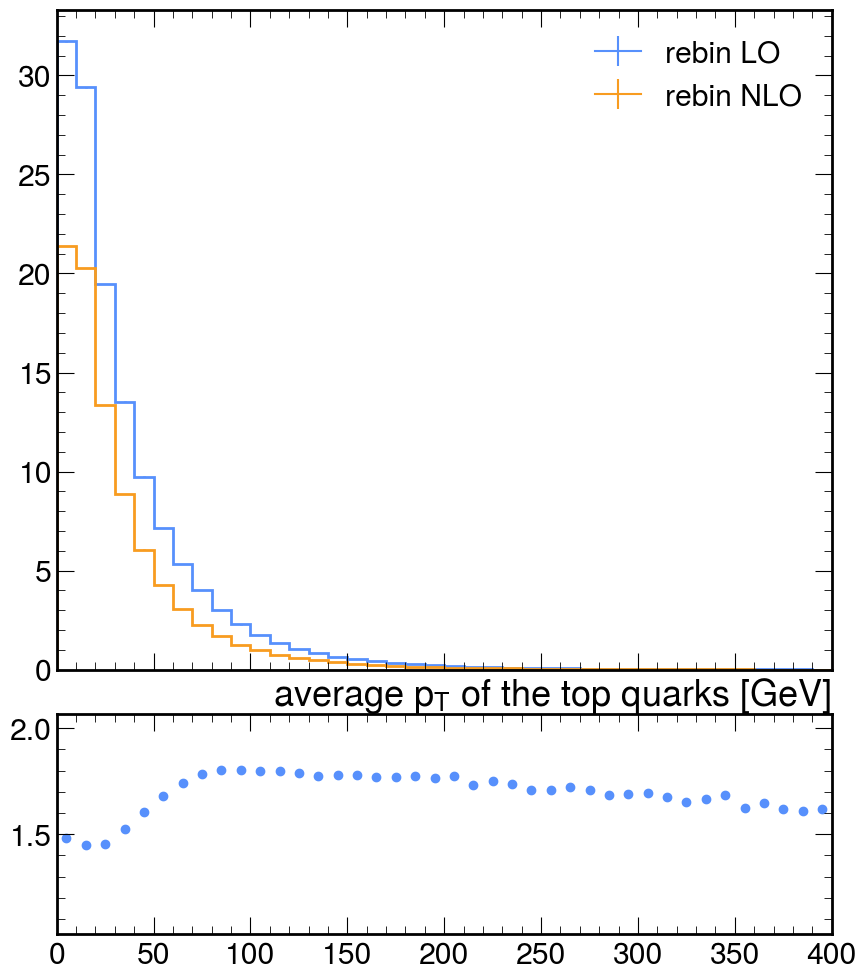

In [174]:
hep.style.use('CMS')
fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10,12),
    gridspec_kw={'height_ratios': (3, 1)},
    sharex=True
)
fig.subplots_adjust(hspace=.1)

# hep.histplot(h_NLO, ax=ax, stack=False, yerr=False, linewidth=2, label='NLO')
# hep.histplot(h_LO, ax=ax, stack=False, yerr=True, linewidth=2, label='LO')
hep.histplot(h_rebin, ax=ax, stack=False, yerr=True, linewidth=2, label='rebin LO')
hep.histplot(h_NLO_rebin, ax=ax, stack=False, yerr=True, linewidth=2, label='rebin NLO')

ratio = h_rebin.values()/h_NLO_rebin.values()
centers = h_rebin.axes.centers[0]
rax.scatter(centers, ratio)
# hep.histplot(
#     ratio,
#     yerr=False,
#     histtype='errorbar',
#     markersize=12,
#     color='black',
#     ax=rax,
# )  

ax.legend()
ax.set_xlim([0,400])
# ax.set_ylim([0.1, 1])
# ax.set_yscale('log')

In [252]:
NLO_sample = pickle.load(gzip.open("../LOtoNLO/PowhegLOtoNLO_varbins.pkl.gz"))
h_NLO = NLO_sample['ttbar']['avg_toppt'].project('avg_toppt')

LO_sample = pickle.load(gzip.open("../LOtoNLO/SMEFTsimLOtoNLO_varbins.pkl.gz"))
h_LO = LO_sample['ttbar']['avg_toppt'].project('avg_toppt')
# print(np.sum(h_LO.values()))
# np.sum((h_NLO.values()))

/tmp/ipykernel_4031059/204614012.py:15: RuntimeWarning: invalid value encountered in divide
  ratio = h_NLO.values()/h_LO.values()


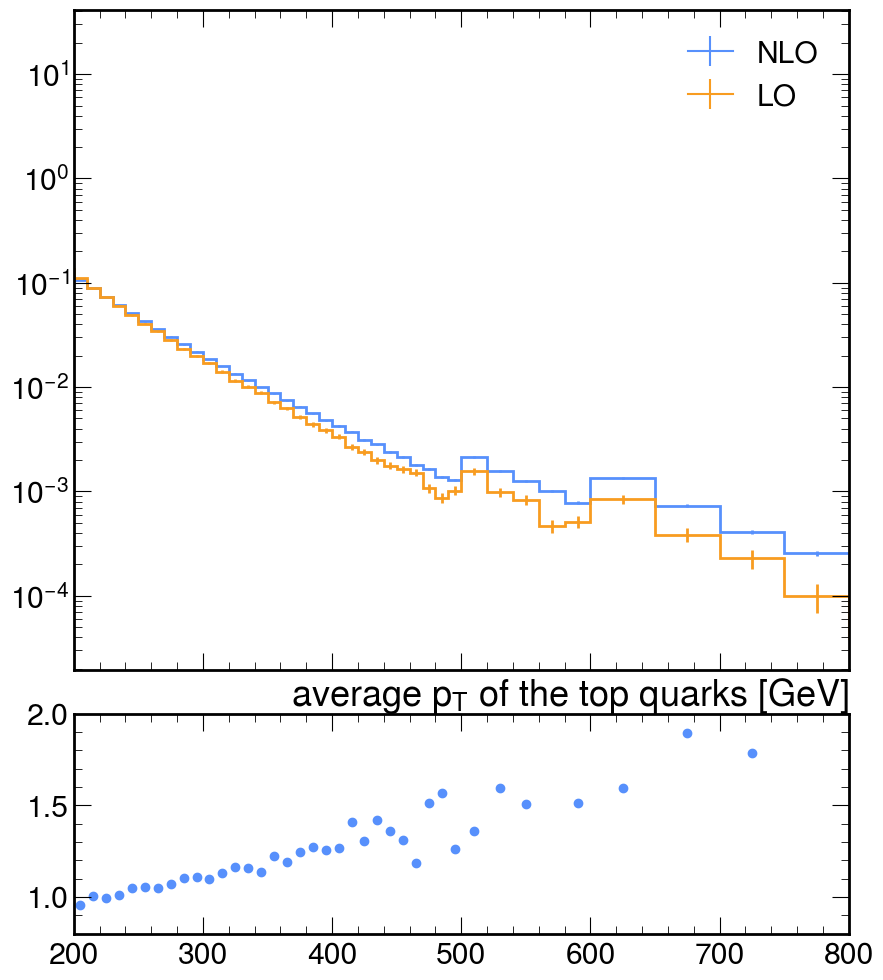

In [253]:
hep.style.use('CMS')
fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10,12),
    gridspec_kw={'height_ratios': (3, 1)},
    sharex=True
)
fig.subplots_adjust(hspace=.1)

# hep.histplot(const_bins_NLO, ax=ax, stack=False, yerr=True, linewidth=2, label='NLO')
hep.histplot(h_NLO, ax=ax, stack=False, yerr=True, linewidth=2, label='NLO')
hep.histplot(h_LO, ax=ax, stack=False, yerr=True, linewidth=2, label='LO')

ratio = h_NLO.values()/h_LO.values()
centers = h_LO.axes.centers[0]
rax.scatter(centers, ratio)
# centers = h_rebin.axes.centers[0]
# rax.scatter(centers, ratio)
# ratio = h_NLO/h_LO
# hep.histplot(
#     ratio,
#     yerr=False,
#     histtype='errorbar',
#     markersize=12,
#     color='black',
#     ax=rax,
# )  
rax.set_ylim([0.8, 2])
ax.legend()
ax.set_xlim([200,800])
# ax.set_xlim([400,1000])
# ax.set_ylim([0, 0.01])
# ax.set_ylim([0.1, 1])
ax.set_yscale('log')

In [267]:
new_LO_sample = pickle.load(gzip.open("../LOtoNLO/new_SMEFTsimLOtoNLO_varbins.pkl.gz"))
h_new = new_LO_sample['ttbar']['avg_toppt']

/tmp/ipykernel_4031059/3993369593.py:11: RuntimeWarning: invalid value encountered in divide
  ratio_old = h_NLO.values()/h_LO.values()
/tmp/ipykernel_4031059/3993369593.py:15: RuntimeWarning: divide by zero encountered in divide
  ratio = h_NLO.values()/h_new.values()
/tmp/ipykernel_4031059/3993369593.py:15: RuntimeWarning: invalid value encountered in divide
  ratio = h_NLO.values()/h_new.values()


(0.8, 2.0)

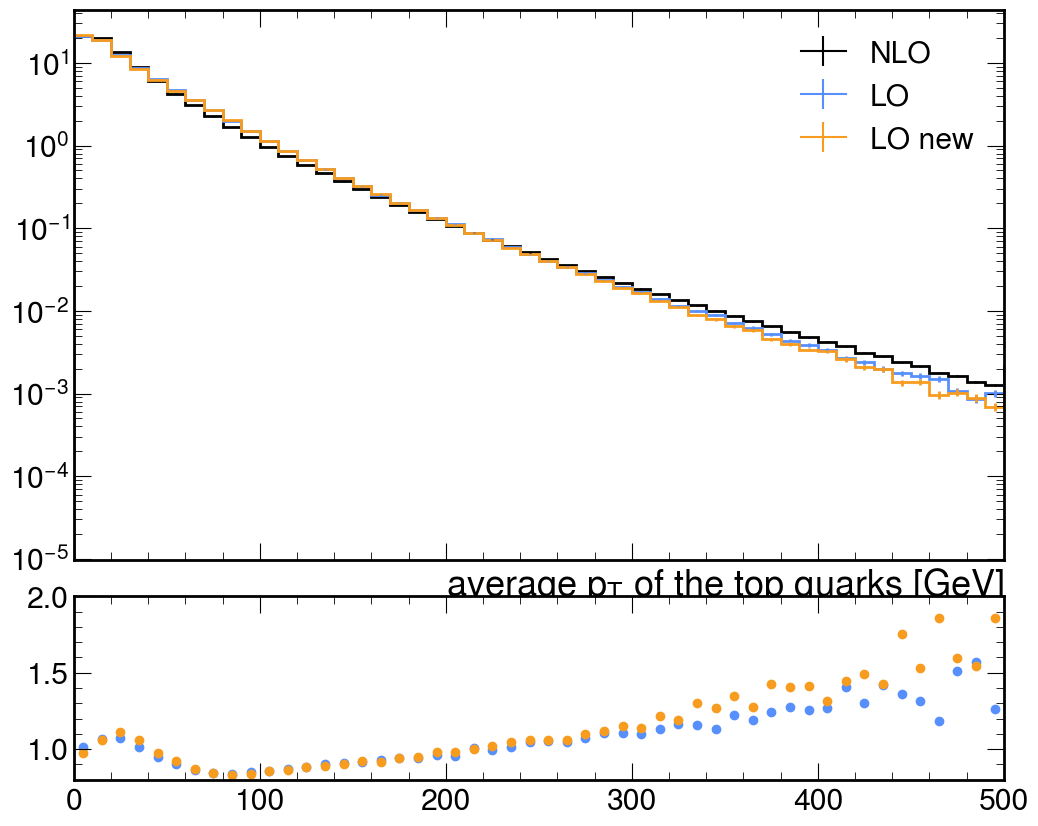

In [269]:
hep.style.use('CMS')
fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12,10),
    gridspec_kw={'height_ratios': (3, 1)},
    sharex=True
)
fig.subplots_adjust(hspace=.1)

ratio_old = h_NLO.values()/h_LO.values()
centers_old = h_LO.axes.centers[0]
rax.scatter(centers_old, ratio_old, label='old')

ratio = h_NLO.values()/h_new.values()
centers = h_new.axes.centers[0]
rax.scatter(centers, ratio, label="new")

hep.histplot(h_NLO, ax=ax, stack=False, yerr=True, linewidth=2, label='NLO', color='black')
hep.histplot(h_LO, ax=ax, stack=False, yerr=True, linewidth=2, label='LO')
hep.histplot(h_new, ax=ax, stack=False, yerr=True, linewidth=2, label='LO new')

ax.legend()
ax.set_yscale('log')
ax.set_xlim([0, 500])
rax.set_ylim([0.8, 2])

ValueError: operands could not be broadcast together with shapes (44,) (47,) 

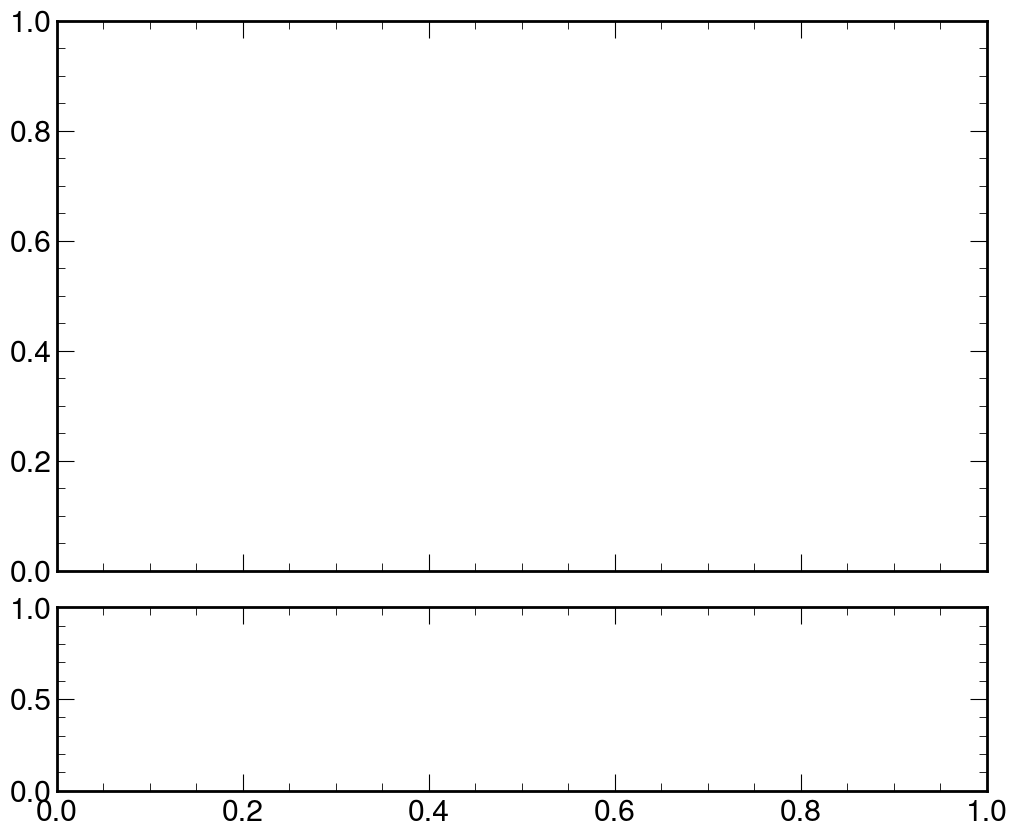

In [276]:
NLO_sample2 = pickle.load(gzip.open("PowhegLOtoNLO_varbins2.pkl.gz"))
h_NLO2 = NLO_sample2['ttbar']['avg_toppt']
new_LO_sample2 = pickle.load(gzip.open("new_SMEFTsimLOtoNLO_varbins2.pkl.gz"))
h_new2 = new_LO_sample2['ttbar']['avg_toppt']

hep.style.use('CMS')
fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12,10),
    gridspec_kw={'height_ratios': (3, 1)},
    sharex=True
)
fig.subplots_adjust(hspace=.1)

ratio = h_NLO2.values()/h_new2.values()
centers = h_new2.axes.centers[0]
rax.scatter(centers, ratio, label="new")

hep.histplot(h_NLO2, ax=ax, stack=False, yerr=True, linewidth=2, label='NLO', color='black')
hep.histplot(h_new2, ax=ax, stack=False, yerr=True, linewidth=2, label='LO')

ax.legend()
ax.set_yscale('log')
ax.set_xlim([850, 2000])
rax.set_ylim([0.8, 2])